# SPARC-UQ: from point forecasts to interpretable uncertainty

**An executable visual guide to the reusable SPARC core.** We attach uncertainty
to a fixed constant-velocity forecaster, calibrate on held-out rows, and inspect
what its feature-leverage scale can and cannot tell us.

[Paper (ECCV 2026)](https://arxiv.org/abs/2608.20802) |
[Code](https://github.com/julianteusch/sparc-uq) |
[Project](https://julianteusch.github.io/projects/sparc/)

**Scope:** synthetic two-joint trajectories and a manually specified covariance.
This is an integration tutorial, not the learned covariance head, real motion
data, or a reproduction of the paper's benchmark results. All figures below are
generated by the code, not hand-drawn performance illustrations.

From a cloned repository, install with `python -m pip install -e '.[notebook]'`,
then open this notebook with `jupyter lab`. Run the cells in order. No downloads,
GPU, external checkpoints, hidden services or notebook-side package installs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

from sparc import SPARC, Forecast, explain_leverage, graph_temporal_factor
from sparc.visualization import (
    plot_calibration,
    plot_covariance,
    plot_feature_support,
    plot_forecast,
    plot_leverage_terms,
    plot_risk_diagnostic,
)

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")
torch.set_num_threads(2)
generator = torch.Generator().manual_seed(162)
export_dir = Path("artifacts/notebook")
export_dir.mkdir(parents=True, exist_ok=True)


def display_and_export(figure, name):
    figure.savefig(export_dir / f"{name}.png", dpi=150, bbox_inches="tight")
    figure.savefig(export_dir / f"{name}.svg", bbox_inches="tight")
    plt.show()
    plt.close(figure)


print(f"PyTorch {torch.__version__}; deterministic synthetic seed: 162; CPU")

PyTorch 2.2.1; deterministic synthetic seed: 162; CPU


## 1. Keep the existing point estimator

Each input contains the current positions and velocities of two joints in 2D.
The point forecast is simply **position + time x velocity**. SPARC will not
change this forecast or retrain it.

The custom adapter returns the mean, its explicit time-dependent design vector,
and a base covariance factor. We choose temporally correlated noise and a graph
connecting the two joints. In real use this covariance would come from your
independently fitted, frozen covariance head, or the package's diagonal fallback.

In [2]:
H, C = 8, 4
time = torch.linspace(0.1, 0.8, H)
lags = (torch.arange(H)[:, None] - torch.arange(H)).abs()
temporal_factor = torch.linalg.cholesky(0.04 * 0.65**lags)
base_factor = graph_temporal_factor(
    temporal_factor[None],
    torch.tensor([[0.0, 1.0], [1.0, 0.0]]),
    tau=0.5,
    epsilon=1.0,
    coordinates=2,
)
feature_names = [
    "A position x",
    "A position y",
    "B position x",
    "B position y",
    "A velocity x * t",
    "A velocity y * t",
    "B velocity x * t",
    "B velocity y * t",
    "Bias",
]


def point_forecaster(x):
    return x[:, None, :C] + time[None, :, None] * x[:, None, C:]


def adapter(x):
    features = torch.cat(
        [
            x[:, None, :C].expand(-1, H, -1),
            time[None, :, None] * x[:, None, C:],
            torch.ones(len(x), H, 1),
        ],
        dim=-1,
    )
    return Forecast(
        mean=point_forecaster(x),
        features=features,
        covariance_factor=base_factor.expand(len(x), -1, -1),
    )


def make_data(n):
    x = torch.randn(n, 2 * C, generator=generator)
    noise = torch.randn(n, H * C, generator=generator) @ base_factor[0].T
    return x, point_forecaster(x) + noise.reshape(n, H, C)


# Three disjoint, independently generated sets of complete trajectories.
fit_x, fit_y = make_data(256)
cal_x, cal_y = make_data(512)
test_x, test_y = make_data(512)
print("Input shape:", tuple(fit_x.shape), "Target shape:", tuple(fit_y.shape))

Input shape: (256, 8) Target shape: (256, 8, 4)


## 2. Fit statistics, then calibrate on separate rows

SPARC estimates one feature precision per horizon:

$\Lambda_t = \lambda I + \sum_i \phi_t(x_i)\phi_t(x_i)^T$,
$\quad \kappa_t(x) = 1 + \phi_t(x)^T\Lambda_t^{-1}\phi_t(x)$.

A feature vector with less support in the fitted representation can receive a
larger scale. Cholesky solves evaluate the quadratic form without an explicit
inverse. The covariance factor is row-scaled by $\sqrt{\kappa_t}$.

**Only after this fit** do we use calibration residuals to choose interval
multipliers. The default is a separate marginal quantile per horizon/coordinate.
We do not tune model choices on these calibration or test rows.

In [3]:
uq = SPARC(adapter, model_id="notebook-constant-velocity-v1/graph-v1", alpha=0.05)
uq.fit([(fit_x, fit_y)])
uq.calibrate([(cal_x, cal_y)])
prediction = uq.predict(test_x)
torch.testing.assert_close(prediction.mean, point_forecaster(test_x))
assert (prediction.kappa >= 1).all()
print("Point predictions unchanged.")
print(f"Fit rows: {uq.leverage.n_fit}; calibration rows: {uq.calibration.n_calibration}")
print(f"Test kappa range: {prediction.kappa.min():.4f} to {prediction.kappa.max():.4f}")

Point predictions unchanged.
Fit rows: 256; calibration rows: 512
Test kappa range: 1.0086 to 1.1370


## 3. Read a forecast, not just a point

The green line is the unchanged forecast. The orange points are the observed
future. The shaded region shows conformal intervals at the discrete forecast
steps. Joining their boundaries is a visual aid, **not a guarantee between steps
or a claim that the entire trajectory is covered simultaneously**.

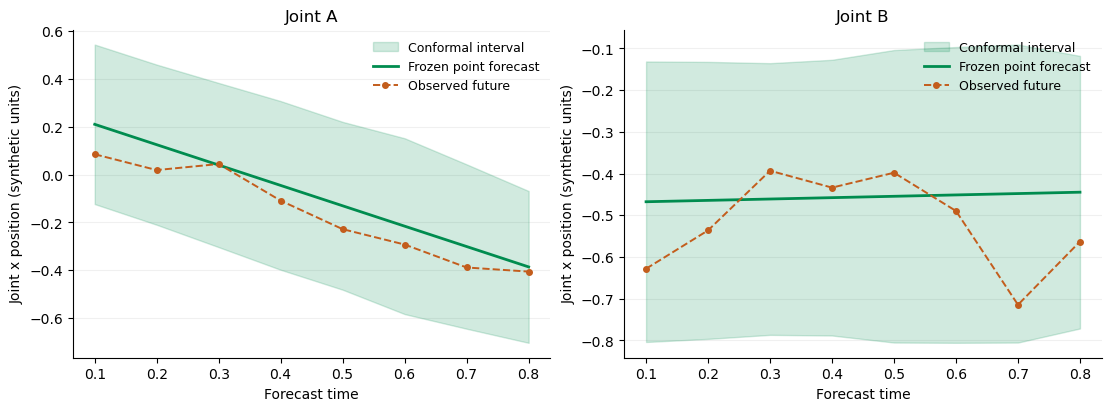

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for channel, ax in zip((0, 2), axes, strict=True):
    plot_forecast(prediction, test_y, sample=0, channel=channel, times=time.tolist(), ax=ax)
    ax.set_ylabel("Joint x position (synthetic units)")
    ax.set_title("Joint A" if channel == 0 else "Joint B")
display_and_export(fig, "01-forecast-intervals")

## 4. Inspect coverage together with width

Coverage alone can be improved by making intervals needlessly wide. These two
panels show empirical coverage and width on the untouched test set. Coordinates
are averaged **for display only**, not pooled for conformal fitting.

Even a valid 95% marginal procedure need not attain exactly 95% in one finite
test sample. We omit binomial error bars because coordinates within a trajectory
are dependent. The theoretical assumption concerns exchangeability of complete
rows; splitting overlapping real-world windows does not establish it.

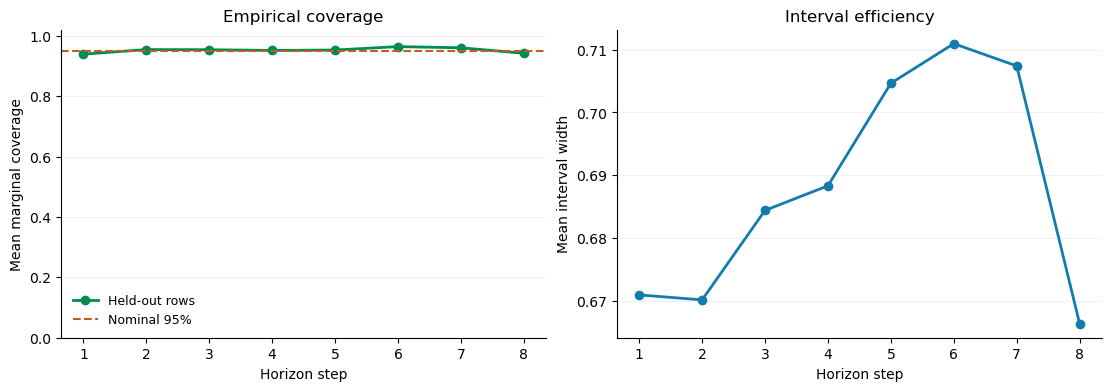

Empirical mean marginal coverage: 95.203%
Mean interval width: 0.6879


In [5]:
axes = plot_calibration(prediction, test_y, nominal=1 - uq.calibration.alpha)
display_and_export(axes[0].figure, "02-coverage-and-width")
covered = (test_y >= prediction.lower) & (test_y <= prediction.upper)
print(f"Empirical mean marginal coverage: {covered.double().mean():.3%}")
print(f"Mean interval width: {(prediction.upper - prediction.lower).mean():.4f}")

## 5. Explore weak feature support without claiming an OOD guarantee

We now create a few **deliberately shifted queries** with large joint-A
velocities. They are used to inspect the leverage calculation, not to evaluate
the conformal guarantee. These queries do not follow the calibration distribution.

The plot shows only two of nine design dimensions at the last horizon. Its
distances do not determine the full-space score. A large $\kappa$ is a
representation-dependent diagnostic, not proof of an inaccurate forecast or
a universal out-of-distribution detector.

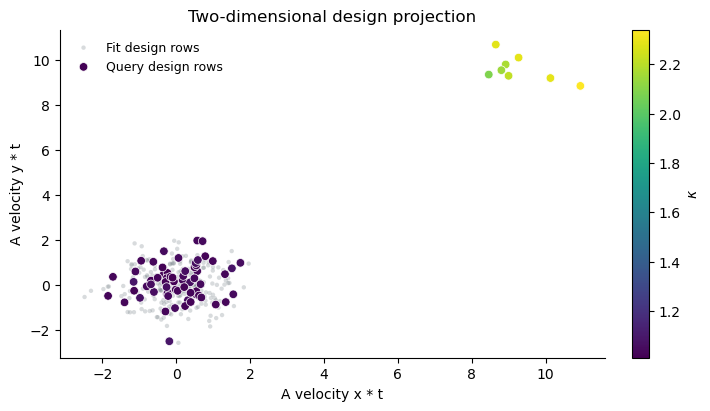

Shifted queries: inspection only; no coverage claim.


In [6]:
shifted_x = test_x[:8].clone()
shifted_x[:, 4:6] += 12
query_x = torch.cat([test_x[:64], shifted_x])
query_features = adapter(query_x).features
query_prediction = uq.predict(query_x)
ax = plot_feature_support(
    adapter(fit_x).features[:, -1],
    query_features[:, -1],
    query_prediction.kappa[:, -1],
    dimensions=(4, 5),
    feature_names=feature_names,
)
display_and_export(ax.figure, "03-feature-support")
print("Shifted queries: inspection only; no coverage claim.")

## 6. Expand the covariance while preserving correlations

For one shifted query, compare the base covariance with
$D\Sigma D$, where $D$ contains horizon-wise $\sqrt{\kappa_t}$ repeated across
coordinates. The top panels share a common color scale; the bottom panels use
the fixed correlation range [-1, 1].

Positive diagonal congruence preserves correlations. It does **not** generally
preserve covariance eigenvectors when the scaling differs across horizons.
These matrices are model covariances, not joint distributions made calibrated
by the conformal interval quantiles. The larger query is selected to make the
scaling visible, not to claim a performance improvement.

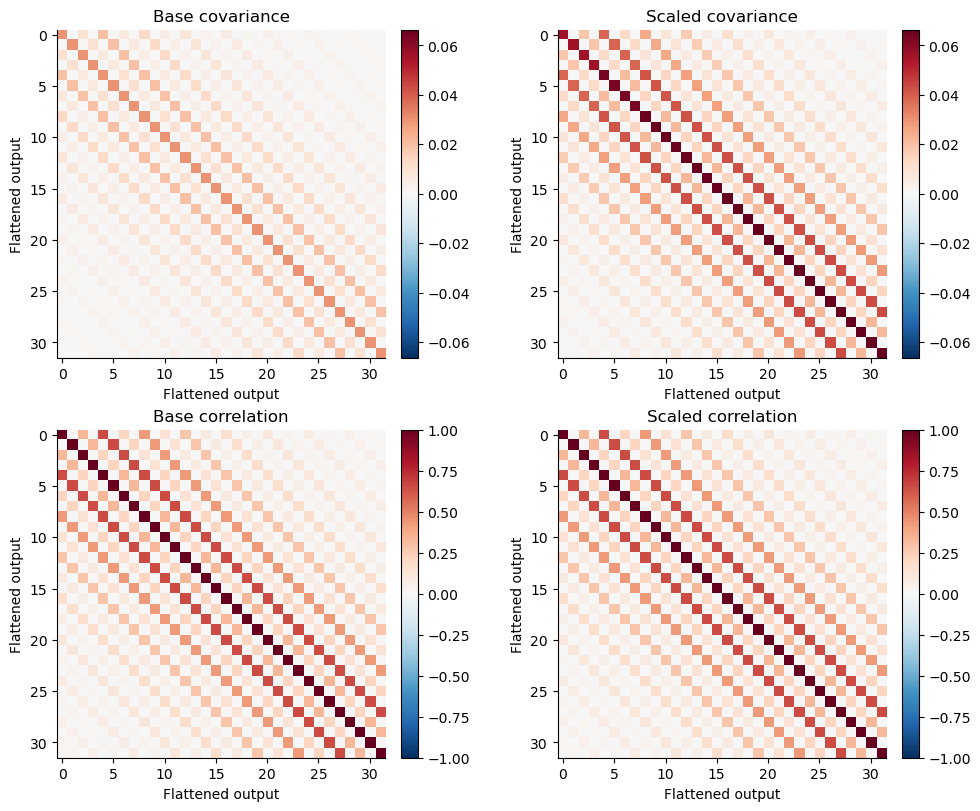

Correlation-preservation check passed.


In [7]:
selected = len(query_x) - 1
base_cov = (base_factor[0] @ base_factor[0].T).double()
scaled_factor = query_prediction.covariance_factor[selected]
scaled_cov = scaled_factor @ scaled_factor.T
limit = max(base_cov.abs().max().item(), scaled_cov.abs().max().item())
fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout="constrained")
for column, (name, matrix) in enumerate([("Base", base_cov), ("Scaled", scaled_cov)]):
    plot_covariance(matrix, vmin=-limit, vmax=limit, ax=axes[0, column])
    axes[0, column].set_title(f"{name} covariance")
    plot_covariance(matrix, correlation=True, ax=axes[1, column])
    axes[1, column].set_title(f"{name} correlation")
display_and_export(fig, "04-covariance-and-correlation")


def correlation(matrix):
    std = matrix.diagonal().sqrt()
    return matrix / std[:, None] / std[None, :]


torch.testing.assert_close(correlation(base_cov), correlation(scaled_cov), atol=1e-6, rtol=1e-6)
print("Correlation-preservation check passed.")

## 7. Explain the scale in its design basis

`explain_leverage` provides an exact, signed decomposition:

$c_p = \phi_p (\Lambda^{-1}\phi)_p$,
$\quad \sum_p c_p = \kappa-1$,
$\quad \nabla_\phi\kappa = 2\Lambda^{-1}\phi$.

Green bars are positive terms; orange bars are negative terms caused by cross
terms in the quadratic form. The contribution plot is **not SHAP, not a
counterfactual feature-removal effect, and not causal importance**. The terms
depend on representation and basis; sensitivities additionally depend on units.
The final bias coordinate is part of the model design, not a measured input.

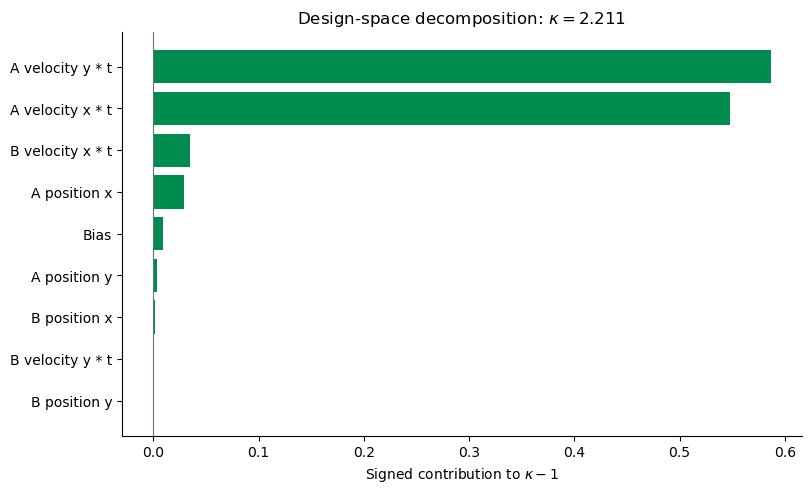

Signed terms sum to kappa - 1.
Local sensitivity to the first two DESIGN coordinates:
tensor([-0.0276, -0.0043], dtype=torch.float64)


In [8]:
explanation = explain_leverage(uq.leverage, query_features)
torch.testing.assert_close(explanation.terms.sum(-1), explanation.kappa - 1)
ax = plot_leverage_terms(
    explanation,
    sample=selected,
    horizon=H - 1,
    feature_names=feature_names,
)
display_and_export(ax.figure, "05-leverage-decomposition")
print("Signed terms sum to kappa - 1.")
print("Local sensitivity to the first two DESIGN coordinates:")
print(explanation.sensitivity[selected, -1, :2])

## 8. Check the risk signal against actual error

We return to the unshifted held-out test rows. Each point below is one complete
trajectory: average horizon $\kappa$ versus observed RMSE.

In this synthetic generator the point-forecast rule is correct and the noise
covariance is fixed. **We therefore should not expect a strong monotone relation
between leverage and realized error.** A diagnostic becomes useful through
empirical validation on the intended task, not by calling it an epistemic score.
This panel is descriptive; do not select deployment thresholds on the test set.

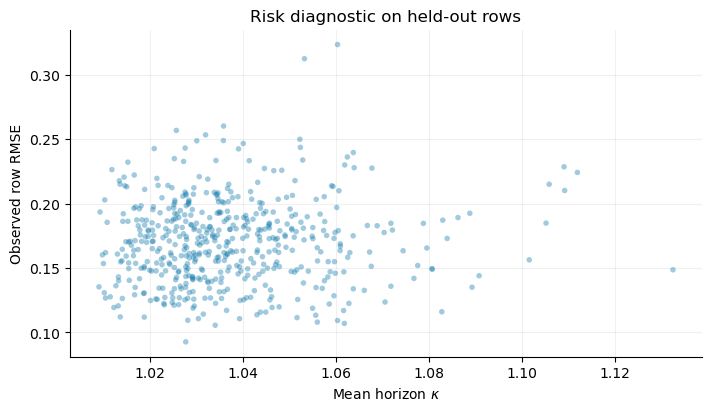

In [9]:
ax = plot_risk_diagnostic(prediction, test_y)
display_and_export(ax.figure, "06-risk-diagnostic")

## 9. Save state and use the same tools with your predictor

Saving preserves fitted uncertainty statistics and quantiles, not your original
predictor. Restore the same weights, feature map, covariance and preprocessing
separately. `model_id` is a compatibility label, not an automatic weight hash.

For an MLP returning a literal final `nn.Linear` output, use
`LinearLastLayerAdapter(model, model.output_layer)`. For custom architectures,
return `Forecast(mean, features, ...)` from one deterministic evaluation, as
above. Helpers accept Matplotlib axes, do not call `show`, and do not modify the
predictor. This notebook exports PNG and SVG figures into `artifacts/notebook/`.

In [10]:
uq.save(export_dir / "example-uq.pt")
restored = SPARC.load(export_dir / "example-uq.pt", adapter, model_id=uq.model_id)
torch.testing.assert_close(prediction.lower, restored.predict(test_x).lower)
print("Save/load check passed. Six figure sets exported as PNG and SVG.")

Save/load check passed. Six figure sets exported as PNG and SVG.


## References and next steps

- Hossain, Teusch and Mueller (2026),
  [SPARC: Single-Pass Scaling for Motion Forecasting with Conformal Bayesian Last Layers](https://arxiv.org/abs/2608.20802).
  Please cite this paper if you use the method in research; see the repository's
  `CITATION.cff` and README BibTeX entry.
- Angelopoulos and Bates,
  [A Gentle Introduction to Conformal Prediction](https://arxiv.org/abs/2107.07511).
- See [the integration guide](https://github.com/julianteusch/sparc-uq/blob/main/docs/integration.md)
  and [visualization contracts](https://github.com/julianteusch/sparc-uq/blob/main/docs/visualization.md).

Before drawing application conclusions, replace the synthetic generator, specify
independent calibration units, evaluate coverage and width on an untouched test
split, and validate whether leverage actually identifies high-error cases.
The complete learned graph-temporal paper pipeline remains a separate release.